In [21]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import seaborn as sns
from kmodes.kprototypes import KPrototypes
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules
from kmodes.kmodes import KModes

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [4]:
df = pd.read_excel('emergency-department-volume-and-capacity-2021-2023.xlsx')

<Axes: xlabel='Tot_ED_NmbVsts', ylabel='Count'>

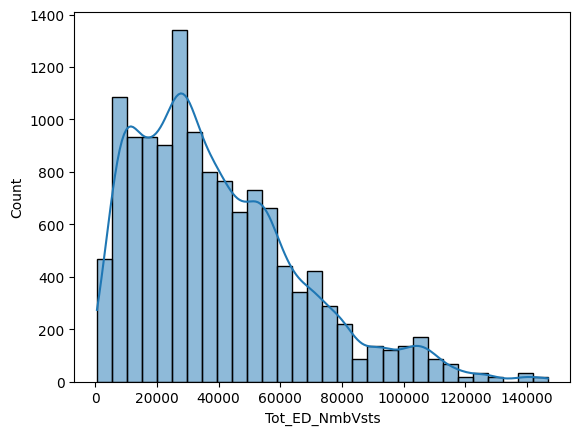

In [5]:
sns.histplot(df['Tot_ED_NmbVsts'], bins=30, kde=True)

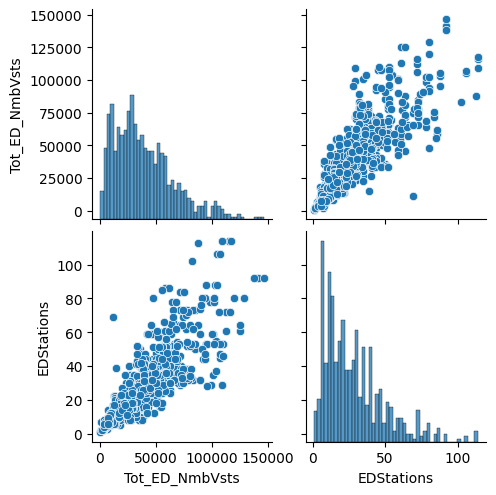

In [6]:
sns.pairplot(df[['Tot_ED_NmbVsts', 'EDStations', 'LICENSED_BED_SIZE']])

<Axes: xlabel='LICENSED_BED_SIZE', ylabel='Tot_ED_NmbVsts'>

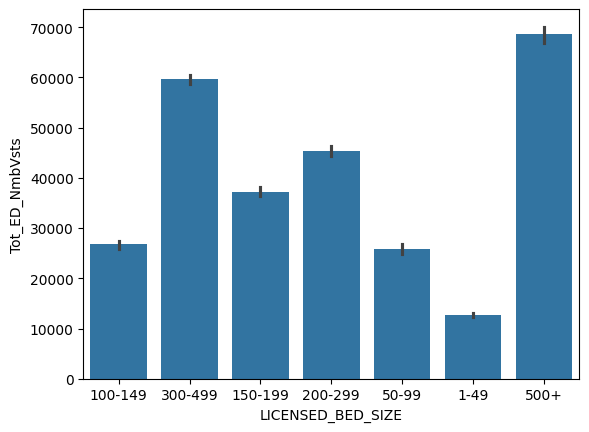

In [7]:
sns.barplot(x='LICENSED_BED_SIZE', y='Tot_ED_NmbVsts', data=df)

In [ ]:
df['TEACHINGDesignation'].fillna('Non-Teaching', inplace=True)
df['system'].fillna('N/A', inplace=True)
df = df[(df['Tot_ED_NmbVsts'] > 0) & (df['EDStations'] > 0)]

In [ ]:
bed_mapping = {'1-49': 1, '50-99': 2, '100-149': 3, '150-199': 4, '200-299': 5, '300-499': 6, '500+': 7}
df['Bed_Size_Encoded'] = df['LICENSED_BED_SIZE'].map(bed_mapping)

In [ ]:
categorical_cols = ['HospitalOwnership', 'UrbanRuralDesi', 'TEACHINGDesignation', 'PrimaryCareShortageArea']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [ ]:
features = ['Bed_Size_Encoded', 'EDStations'] + [col for col in df_encoded.columns if 'HospitalOwnership_' in col or 'UrbanRuralDesi_' in col]
df_model = df_encoded.dropna(subset=features + ['Visits_Per_Station'])


In [ ]:
X = df_model[features]
y = df_model['Visits_Per_Station']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

In [ ]:

print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("Random Forest R2:", r2_score(y_test, y_pred_rf))

1.	Assess capacity strain and overcrowding by identifying the overburdened hospitals based on the encounters per treatment station by identifying drivers which cohorts contribute most to high burden and try to mitigate the same using under burdened departments in the hospital.

In [ ]:
df = pd.read_excel('emergency-department-volume-and-capacity-2021-2023.xlsx')

In [22]:
df['Visits_Per_Station'] = df['Tot_ED_NmbVsts'] / (df['EDStations'] + 1e-5)
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=['Visits_Per_Station'])

high_burden_threshold = df['Visits_Per_Station'].quantile(0.75)
low_burden_threshold = df['Visits_Per_Station'].quantile(0.25)

df['Burden_Status'] = pd.cut(
    df['Visits_Per_Station'], 
    bins=[-np.inf, low_burden_threshold, high_burden_threshold, np.inf], 
    labels=['Under-Burdened', 'Normal', 'Overburdened']
)

print("\n--- Capacity Strain Overview ---")
print(df['Burden_Status'].value_counts())




print("\n--- Training Regression Models ---")
features = ['CountyName', 'HospitalOwnership', 'LICENSED_BED_SIZE', 'EDStations']
X = df[features]
y = df['Visits_Per_Station']

categorical_cols = ['CountyName', 'HospitalOwnership', 'LICENSED_BED_SIZE']
numerical_cols = ['EDStations']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


--- Capacity Strain Overview ---
Burden_Status
Normal            6424
Under-Burdened    3214
Overburdened      3194
Name: count, dtype: int64

--- Training Regression Models ---


In [23]:

models = {
    'Random Forest Regressor': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost Regressor': XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
    'Support Vector Regression': SVR(kernel='rbf', C=100, gamma='scale')
}

results = {}
for name, model in models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    results[name] = {'MAE': mae, 'RMSE': rmse}

results_df = pd.DataFrame(results).T
print("\n--- Model Evaluation Results ---")
print(results_df.round(2))


--- Model Evaluation Results ---
                              MAE    RMSE
Random Forest Regressor     89.28  136.12
XGBoost Regressor          188.00  257.61
Support Vector Regression  202.13  360.50


2.	Identifying the hospitals based on the clustering specifying the specialization catered, presence of the primary health care and mental health care, bed sizes, hospital ownership.

In [27]:
df = pd.read_excel('emergency-department-volume-and-capacity-2021-2023.xlsx')
categorical_cols = [
    'HospitalOwnership', 
    'LICENSED_BED_SIZE', 
    'PrimaryCareShortageArea', 
    'MentalHealthShortageArea', 
]
numerical_cols = ['EDStations']

df_clean = df.dropna(subset=categorical_cols + numerical_cols).copy()
scaler = StandardScaler()
df_clean['EDStations_Scaled'] = scaler.fit_transform(df_clean[['EDStations']])
kproto_data = df_clean[categorical_cols + ['EDStations_Scaled']]

categorical_indices = [kproto_data.columns.get_loc(col) for col in categorical_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
    ])
X_encoded = preprocessor.fit_transform(df_clean)


--- Running Elbow Method for K-Prototypes ---
K=2 Cost: 15848.07
K=3 Cost: 12486.73
K=4 Cost: 10061.75
K=5 Cost: 9084.10
K=6 Cost: 8663.74
K=7 Cost: 7931.58


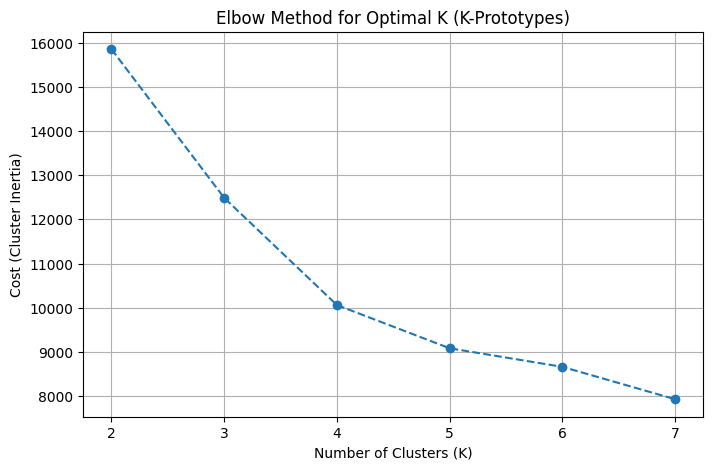

In [28]:
print("\n--- Running Elbow Method for K-Prototypes ---")
costs = []
K_range = range(2, 8)

for k in K_range:
    # Initialize K-Prototypes
    kproto = KPrototypes(n_clusters=k, init='Cao', random_state=42, n_jobs=-1)
    kproto.fit(kproto_data, categorical=categorical_indices)
    costs.append(kproto.cost_)
    print(f"K={k} Cost: {kproto.cost_:.2f}")

# Plotting the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(K_range, costs, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K (K-Prototypes)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Cost (Cluster Inertia)')
plt.grid(True)
plt.show()

In [29]:
optimal_k = 3
print(f"\nTraining Final K-Prototypes Model with K={optimal_k}...")
final_kproto = KPrototypes(n_clusters=optimal_k, init='Cao', random_state=42, n_jobs=-1)
kproto_clusters = final_kproto.fit_predict(kproto_data, categorical=categorical_indices)
df_clean['KProto_Cluster'] = kproto_clusters

dbscan = DBSCAN(eps=1.5, min_samples=5)
dbscan_clusters = dbscan.fit_predict(X_encoded)
df_clean['DBSCAN_Cluster'] = dbscan_clusters

n_noise = list(dbscan_clusters).count(-1)
print(f"Estimated number of DBSCAN clusters: {len(set(dbscan_clusters)) - (1 if -1 in dbscan_clusters else 0)}")
print(f"Estimated number of noise points: {n_noise}")


def evaluate_clustering(model_name, labels, data):
    if len(set(labels)) > 1:
        sil_score = silhouette_score(data, labels)
        calinski_score = calinski_harabasz_score(data, labels)
        print(f"** {model_name} **")
        print(f"  Silhouette Score: {sil_score:.4f} (Closer to 1 is better, < 0 means overlapping)")
        print(f"  Calinski-Harabasz Index: {calinski_score:.4f} (Higher means denser, more separated clusters)")
    else:
        print(f"** {model_name} **")
        print("  Could not calculate metrics: Only one valid cluster found (or all noise).")

evaluate_clustering("K-Prototypes", df_clean['KProto_Cluster'], X_encoded)
evaluate_clustering("DBSCAN", df_clean['DBSCAN_Cluster'], X_encoded)


for cluster_num in range(optimal_k):
    cluster_data = df_clean[df_clean['KProto_Cluster'] == cluster_num]
    print(f"\nCluster {cluster_num} (Size: {len(cluster_data)} hospitals):")
    for col in categorical_cols:
        top_category = cluster_data[col].mode()[0]
        print(f"  - Dominant {col}: {top_category}")
    avg_stations = cluster_data['EDStations'].mean()
    print(f"  - Average ED Stations: {avg_stations:.1f}")


Training Final K-Prototypes Model with K=3...
Estimated number of DBSCAN clusters: 1
Estimated number of noise points: 0
** K-Prototypes **
  Silhouette Score: 0.1859 (Closer to 1 is better, < 0 means overlapping)
  Calinski-Harabasz Index: 3842.2253 (Higher means denser, more separated clusters)
** DBSCAN **
  Could not calculate metrics: Only one valid cluster found (or all noise).

Cluster 0 (Size: 2768 hospitals):
  - Dominant HospitalOwnership: Nonprofit
  - Dominant LICENSED_BED_SIZE: 300-499
  - Dominant PrimaryCareShortageArea: No
  - Dominant MentalHealthShortageArea: No
  - Average ED Stations: 60.4

Cluster 1 (Size: 6079 hospitals):
  - Dominant HospitalOwnership: Nonprofit
  - Dominant LICENSED_BED_SIZE: 200-299
  - Dominant PrimaryCareShortageArea: No
  - Dominant MentalHealthShortageArea: No
  - Average ED Stations: 24.7

Cluster 2 (Size: 3985 hospitals):
  - Dominant HospitalOwnership: Nonprofit
  - Dominant LICENSED_BED_SIZE: 1-49
  - Dominant PrimaryCareShortageArea: 

3.	Predicting the health care shortage i.e. Primary care shortage based on the visits per station, country name, category, hospital ownership and urban- rural criteria. We can use Binary classification to predict whether there is shortage or not.

In [33]:

from sklearn.preprocessing import LabelEncoder


df['Visits_Per_Station'] = df['Tot_ED_NmbVsts'] / (df['EDStations'] + 1e-5)

features = ['CountyName', 'Category', 'HospitalOwnership', 'UrbanRuralDesi', 'Visits_Per_Station']
target_col = 'PrimaryCareShortageArea'
df = df.dropna(subset=features + [target_col])

le = LabelEncoder()
y = le.fit_transform(df[target_col])
print(f"Target Encoding mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")

X = df[features]

categorical_cols = ['CountyName', 'Category', 'HospitalOwnership', 'UrbanRuralDesi']
numerical_cols = ['Visits_Per_Station']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ])


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)



Target Encoding mapping: {'No': np.int64(0), 'Yes': np.int64(1)}


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, confusion_matrix, roc_auc_score


models = {
    'XGBoost Classifier': XGBClassifier(
        n_estimators=100, 
        learning_rate=0.1, 
        max_depth=5, 
        use_label_encoder=False, 
        eval_metric='logloss',
        random_state=42
    ),
    'LightGBM Classifier': LGBMClassifier(
        n_estimators=100, 
        learning_rate=0.1, 
        max_depth=5, 
        random_state=42,
        verbose=-1 
    )
}

for model_name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_pred_proba = pipeline.predict_proba(X_test)[:, 1] # Probabilities for ROC AUC
    acc = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    print(f"Accuracy:  {acc:.4f}")
    print(f"ROC AUC:   {roc_auc:.4f}\n")
    
    print("Classification Report:")
    # Pass target names for better readability in the report
    print(classification_report(y_test, y_pred, target_names=le.classes_))
    
    print("Confusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    print(pd.DataFrame(cm, index=[f'Actual {c}' for c in le.classes_], columns=[f'Predicted {c}' for c in le.classes_]))


print("\n--- Feature Importance (LightGBM) ---")
lgbm_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', models['LightGBM Classifier'])])
lgbm_pipeline.fit(X_train, y_train)

cat_feature_names = lgbm_pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_cols)
all_feature_names = numerical_cols + list(cat_feature_names)

importances = lgbm_pipeline.named_steps['classifier'].feature_importances_

importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(importance_df.head(10).to_string(index=False))

c:\Users\rajasg1\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:21:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy:  0.9198
ROC AUC:   0.9766

Classification Report:
              precision    recall  f1-score   support

          No       0.90      1.00      0.94      1773
         Yes       0.99      0.75      0.85       794

    accuracy                           0.92      2567
   macro avg       0.94      0.87      0.90      2567
weighted avg       0.93      0.92      0.92      2567

Confusion Matrix:
            Predicted No  Predicted Yes
Actual No           1766              7
Actual Yes           199            595
Accuracy:  0.9026
ROC AUC:   0.9781

Classification Report:
              precision    recall  f1-score   support

          No       0.88      0.99      0.93      1773
         Yes       0.98      0.70      0.82       794

    accuracy                           0.90      2567
   macro avg       0.93      0.85      0.87      2567
weighted avg       0.91      0.90      0.90      2567

Confusion Matrix:
            Predicted No  Predicted Yes
Actual No           1764      

c:\Users\rajasg1\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\rajasg1\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


4.	Predicting Patient diagnosis category profiling i.e. discovering the hidden patterns about types of hospitals attract patients with specific illness based on the categories, teaching designation, hospital ownership, bed sizes, number of visits and visits per station.

In [35]:
df['Visits_Per_Station'] = df['Tot_ED_NmbVsts'] / (df['EDStations'] + 1e-5)


df['Visits_Volume_Bin'] = pd.qcut(df['Tot_ED_NmbVsts'], q=3, labels=['Low Volume', 'Medium Volume', 'High Volume'])
df['Capacity_Strain_Bin'] = pd.qcut(df['Visits_Per_Station'], q=3, labels=['Low Strain', 'Medium Strain', 'High Strain'])

categorical_features = [
    'Category', 
    'TEACHINGDesignation', 
    'HospitalOwnership', 
    'LICENSED_BED_SIZE', 
    'Visits_Volume_Bin', 
    'Capacity_Strain_Bin'
]

df_mining = df[categorical_features].dropna()

transactions = []
for index, row in df_mining.iterrows():
    # Format: "FeatureName=Value" (e.g., "HospitalOwnership=Non-Profit")
    transaction = [f"{col}={row[col]}" for col in df_mining.columns]
    transactions.append(transaction)

te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_fp = pd.DataFrame(te_ary, columns=te.columns_)

frequent_itemsets = fpgrowth(df_fp, min_support=0.05, use_colnames=True)

rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.1)

def is_diagnosis_consequent(consequents):
    return any('Diagnosis_Category' in item for item in consequents)

diagnosis_rules = rules[rules['consequents'].apply(is_diagnosis_consequent)].copy()


diagnosis_rules = diagnosis_rules.sort_values(by=['confidence', 'lift'], ascending=[False, False])

print(f"Found {len(diagnosis_rules)} meaningful rules predicting patient diagnosis profiles.\n")
print("Top 5 Hidden Patterns (Rules):")
for idx, row in diagnosis_rules.head(5).iterrows():
    antecedents = ", ".join(list(row['antecedents']))
    consequents = ", ".join(list(row['consequents']))
    print(f"Rule: IF [{antecedents}] ---> THEN LIKELY [{consequents}]")
    print(f"      (Confidence: {row['confidence']:.2f}, Lift: {row['lift']:.2f})")

Found 0 meaningful rules predicting patient diagnosis profiles.

Top 5 Hidden Patterns (Rules):


In [36]:
print(" K-MODES: PATIENT-HOSPITAL PROFILING CLUSTERS")
km = KModes(n_clusters=4, init='Cao', n_init=5, verbose=0, random_state=42)

clusters = km.fit_predict(df_mining)
df_mining['Cluster'] = clusters

cluster_centroids = pd.DataFrame(km.cluster_centroids_, columns=categorical_features)

for i, row in cluster_centroids.iterrows():
    cluster_size = len(df_mining[df_mining['Cluster'] == i])
    print(f"\n--- Cluster {i} Profile (Contains {cluster_size} hospitals) ---")
    print(f"  * Teaching Status:     {row['TEACHINGDesignation']}")
    print(f"  * Ownership Type:      {row['HospitalOwnership']}")
    print(f"  * Bed Size:            {row['LICENSED_BED_SIZE']}")
    print(f"  * Visit Volume:        {row['Visits_Volume_Bin']}")
    print(f"  * Capacity Strain:     {row['Capacity_Strain_Bin']}")

 K-MODES: PATIENT-HOSPITAL PROFILING CLUSTERS

--- Cluster 0 Profile (Contains 5288 hospitals) ---
  * Teaching Status:     Non-Teaching
  * Ownership Type:      Nonprofit
  * Bed Size:            300-499
  * Visit Volume:        Medium Volume
  * Capacity Strain:     Low Strain

--- Cluster 1 Profile (Contains 3228 hospitals) ---
  * Teaching Status:     Non-Teaching
  * Ownership Type:      Investor Owned
  * Bed Size:            1-49
  * Visit Volume:        Low Volume
  * Capacity Strain:     Medium Strain

--- Cluster 2 Profile (Contains 2934 hospitals) ---
  * Teaching Status:     Non-Teaching
  * Ownership Type:      Nonprofit
  * Bed Size:            200-299
  * Visit Volume:        High Volume
  * Capacity Strain:     High Strain

--- Cluster 3 Profile (Contains 1382 hospitals) ---
  * Teaching Status:     Non-Teaching
  * Ownership Type:      Investor Owned
  * Bed Size:            100-149
  * Visit Volume:        Medium Volume
  * Capacity Strain:     High Strain
